<a href="https://colab.research.google.com/github/Vrinda-2004/Assessmenttest/blob/main/Case_Study_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/content/adult_dataset.csv")
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [8]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [10]:
df.shape

(48842, 15)

In [11]:
df.replace('?',np.nan, inplace =True)

In [12]:
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_31042/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_31042/485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in cat_cols:
  df[col] = encoder.fit_transform(df[col])

In [16]:
from scipy.stats import zscore
z = np.abs(zscore(df[num_cols]))

df = df[(z < 3).all(axis=1)]

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

/tmp/ipykernel_31042/3092995630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = scaler.fit_transform(df[num_cols])


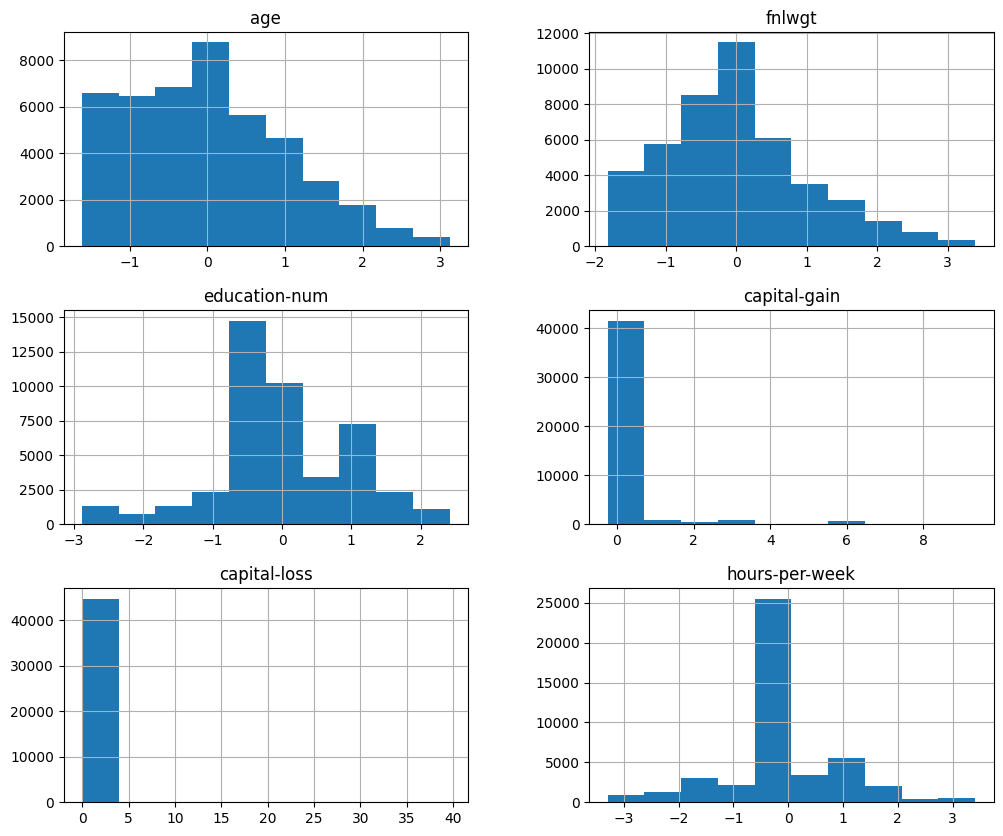

In [18]:
df[num_cols].hist(figsize=(12,10))
plt.show()

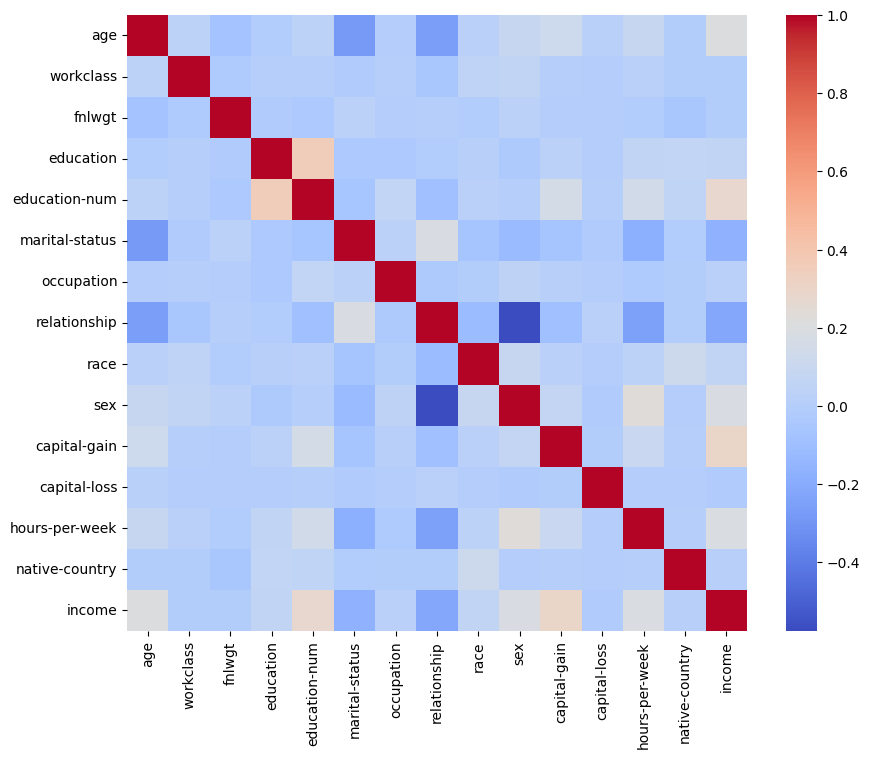

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.show()

In [20]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(df)

In [22]:
from sklearn.cluster import KMeans

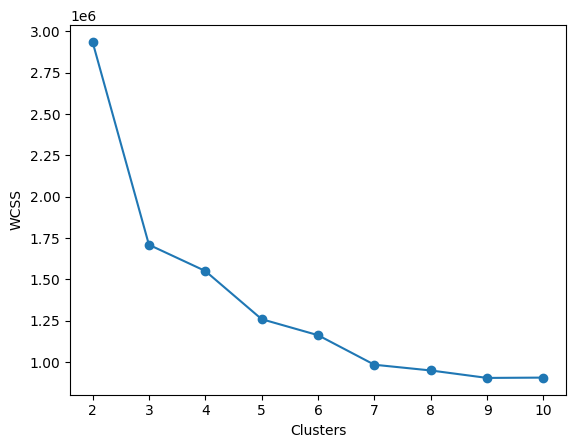

In [23]:
wcss = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(df)
    wcss.append(model.inertia_)

plt.plot(range(2,11), wcss, marker='o')

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

In [24]:
from sklearn.metrics import silhouette_score


In [25]:
for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(df)
    score = silhouette_score(df, labels)
    print(k, score)

2 0.20525933539218616
3 0.2695488903002693
4 0.20744123379307713
5 0.25385931857832683
6 0.21999485191152074
7 0.23185143526238972
8 0.21530558895803456
9 0.2000362819386763
10 0.17707797116351776


In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(df)

df['Cluster'] = clusters

/tmp/ipykernel_31042/2496887425.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = clusters


In [27]:
from sklearn.cluster import AgglomerativeClustering

In [28]:
# Sample 5,000 rows to prevent running out of RAM
df_sample = df.drop('Cluster', axis=1).sample(n=5000, random_state=42)

# Fit Agglomerative Clustering on the sample
agg = AgglomerativeClustering(n_clusters=4)
agg_clusters = agg.fit_predict(df_sample)

# Assign cluster labels to the sampled dataset
df_sample['Agg_Cluster'] = agg_clusters

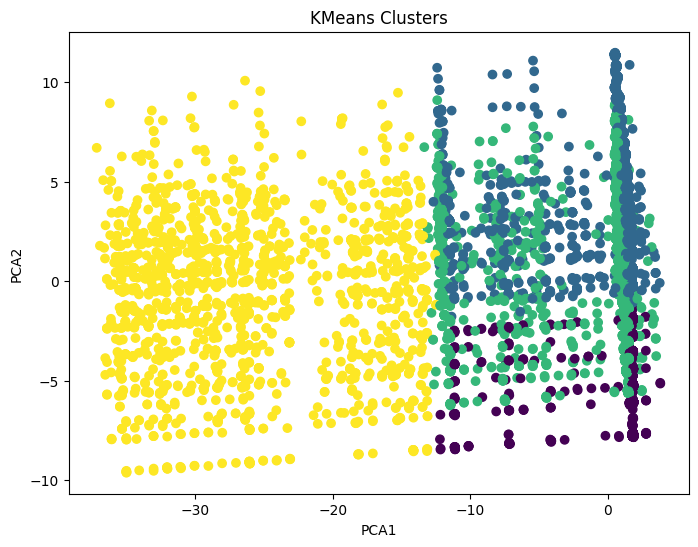

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.title("KMeans Clusters")

plt.show()

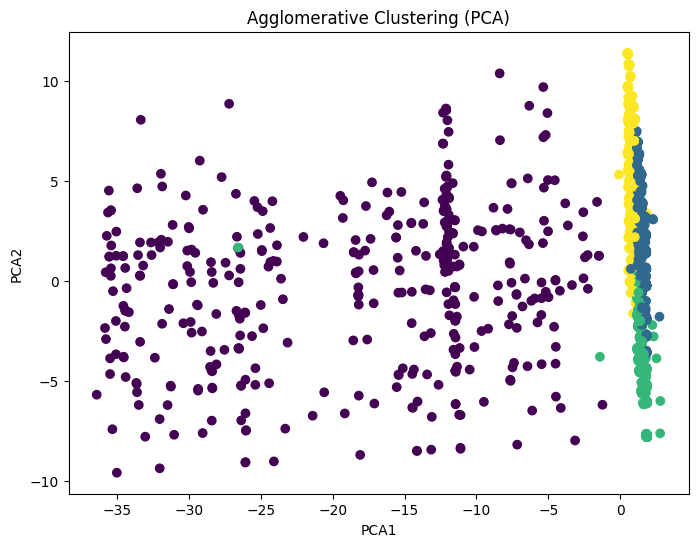

In [35]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Fit Agglomerative Clustering on df_sample
agg = AgglomerativeClustering(n_clusters=4)

# Exclude both 'Cluster' AND 'Agg_Cluster'
X_sample = df_sample.drop(['Cluster', 'Agg_Cluster'], axis=1, errors='ignore')
agg_labels = agg.fit_predict(X_sample)

# 2. Get PCA coordinates specifically for df_sample
pca_sample = pca.transform(X_sample)

# 3. Plot the clusters
plt.figure(figsize=(8,6))
plt.scatter(
    pca_sample[:, 0],
    pca_sample[:, 1],
    c=agg_labels,
    cmap='viridis'
)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Agglomerative Clustering (PCA)")
plt.show()

In [30]:
df.groupby("Cluster").mean()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
Cluster,,,,,,,,,,,,,,,
0,-0.108572,3.099154,-0.014609,14.660671,0.170733,2.609129,3.009976,1.587515,3.675333,0.618501,0.005655,-0.017541,-0.004246,37.748186,0.777963
1,0.025722,3.062049,-0.015379,10.790303,0.208255,2.642513,9.653929,1.452878,3.683974,0.645235,0.019478,0.001602,-0.017265,37.767710,0.820588
2,0.002630,3.105161,0.015285,7.862656,-0.355716,2.612575,3.065402,1.458072,3.698893,0.699281,-0.032254,0.004808,0.027299,37.399534,0.714175
3,0.078827,3.146093,0.103377,9.676670,0.002231,2.678935,6.425255,1.479615,3.188562,0.656852,0.029959,0.004683,-0.018153,10.516421,0.793318


In [31]:
pd.crosstab(df["Cluster"], df["income"])

income,0,1,2,3
Cluster,,,,
0,3478,1647,973,518
1,10514,5322,3440,1659
2,8288,4233,1970,952
3,916,436,277,137
